# BÀI TẬP: EDA HOÀN CHỈNH — TITANIC
## Data Profiling → Descriptive Statistics → Define the Question
**Nguồn:** kaggle.com/c/titanic (891 dòng)

```
PHẦN A — DATA PROFILING       : dữ liệu sạch chưa, có gì
PHẦN B — DESCRIPTIVE STATS    : từng biến trông như thế nào
PHẦN C — DEFINE THE QUESTION  : đặt câu hỏi kinh doanh, trả lời bằng code, rút insight
```

## Setup

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

csv_path = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv'
df = pd.read_csv(csv_path)
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [17]:
print('Số dòng:', df.shape[0], '| Số cột:', df.shape[1])
print()
df.info()

Số dòng: 891 | Số cột: 15

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


## A.2. Missing values & Duplicate data

In [18]:
missing = df.isnull().sum()
print('Missing values:')
print(missing[missing > 0] if missing.sum() > 0 else 'Không có cột nào thiếu dữ liệu.')
print()
print('Duplicate rows:', df.duplicated().sum())

Missing values:
age            177
embarked         2
deck           688
embark_town      2
dtype: int64

Duplicate rows: 107


## A.3. Invalid values

In [19]:
print('survived ngoài [0, 1]:', (~df['survived'].isin([0, 1])).sum())
print('pclass ngoài [1, 3]:', (~df['pclass'].isin([1, 2, 3])).sum())
print('age < 0:', (df['age'] < 0).sum())
print('sibsp < 0:', (df['sibsp'] < 0).sum())
print('parch < 0:', (df['parch'] < 0).sum())
print('fare < 0:', (df['fare'] < 0).sum())
print()
print('Sex values:', df['sex'].unique())
print('Embark towns:', df['embark_town'].dropna().unique())
print()
print('=> Dữ liệu không có giá trị số không hợp lệ.')

survived ngoài [0, 1]: 0
pclass ngoài [1, 3]: 0
age < 0: 0
sibsp < 0: 0
parch < 0: 0
fare < 0: 0

Sex values: <StringArray>
['male', 'female']
Length: 2, dtype: str
Embark towns: <StringArray>
['Southampton', 'Cherbourg', 'Queenstown']
Length: 3, dtype: str

=> Dữ liệu không có giá trị số không hợp lệ.


## A.4. Create a new column
Tạo cột `family_size` = sibsp + parch + 1.

In [20]:
df['family_size'] = df['sibsp'] + df['parch'] + 1
df[['sibsp', 'parch', 'family_size']].head()


,sibsp,parch,family_size
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [21]:
for column in ['age', 'fare', 'family_size']:
    mean_value = df[column].mean()
    median_value = df[column].median()
    mode_value = df[column].mode()[0]
    print(f'{column}: Mean={mean_value:.2f}, Median={median_value:.2f}, Mode={mode_value:.2f}')

age: Mean=29.70, Median=28.00, Mode=24.00
fare: Mean=32.20, Median=14.45, Mode=8.05
family_size: Mean=1.90, Median=1.00, Mode=1.00


## Group 2 — Dispersion

In [22]:
for column in ['age', 'fare', 'family_size']:
    values = df[column]
    range_value = values.max() - values.min()
    std_value = values.std()
    variance_value = values.var()
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    cv = std_value / values.mean()
    print(f'--- {column} ---')
    print(f'Range={range_value:.2f}, Variance={variance_value:.2f}, Std={std_value:.2f}, IQR={iqr:.2f}, CV={cv:.2f}')

--- age ---
Range=79.58, Variance=211.02, Std=14.53, IQR=17.88, CV=0.49
--- fare ---
Range=512.33, Variance=2469.44, Std=49.69, IQR=23.09, CV=1.54
--- family_size ---
Range=10.00, Variance=2.60, Std=1.61, IQR=1.00, CV=0.85


## Group 3 — Location and Shape

--- age ---
P25=20.12, P50=28.00, P75=38.00
Skewness=0.39, Kurtosis=0.17
--- fare ---
P25=7.91, P50=14.45, P75=31.00
Skewness=4.78, Kurtosis=33.20
--- family_size ---
P25=1.00, P50=1.00, P75=2.00
Skewness=2.72, Kurtosis=9.10


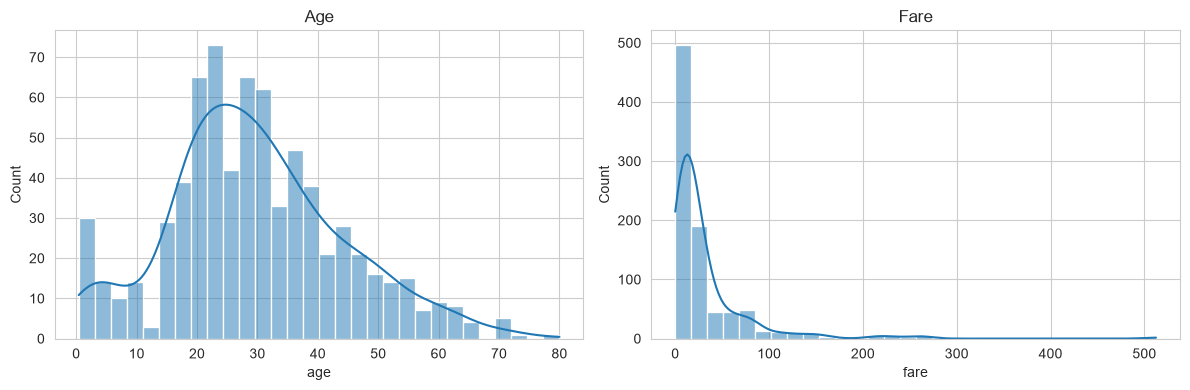

Nhận xét: Fare lệch phải và có nhiều giá trị lớn hơn mức trung vị.


In [23]:
for column in ['age', 'fare', 'family_size']:
    values = df[column].dropna()
    skew_value = stats.skew(values)
    kurtosis_value = stats.kurtosis(values)
    print(f'--- {column} ---')
    print(f'P25={values.quantile(0.25):.2f}, P50={values.quantile(0.50):.2f}, P75={values.quantile(0.75):.2f}')
    print(f'Skewness={skew_value:.2f}, Kurtosis={kurtosis_value:.2f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['age'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Age')
sns.histplot(df['fare'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Fare')
plt.tight_layout()
plt.show()

print('Nhận xét: Fare lệch phải và có nhiều giá trị lớn hơn mức trung vị.')

---
# PHẦN C — DEFINE THE QUESTION

Mỗi câu hỏi theo cấu trúc: **Câu hỏi → Code → Kết quả → Insight**.

## Câu hỏi 1: Hạng vé nào có tỷ lệ sống sót cao nhất, chênh lệch bao nhiêu so với hạng thấp nhất?

In [24]:
survival_by_class = df.groupby('class', observed=True)['survived'].mean().sort_values(ascending=False)
print((survival_by_class * 100).round(2))
print('Difference:', round((survival_by_class.iloc[0] - survival_by_class.iloc[-1]) * 100, 2), 'percentage points')


class
First     62.96
Second    47.28
Third     24.24
Name: survived, dtype: float64
Difference: 38.73 percentage points


**Insight:** Hạng Nhất có tỷ lệ sống sót cao nhất (62.96%), còn hạng Ba thấp nhất (24.24%). Chênh lệch giữa hai hạng là 38.73 điểm phần trăm, cho thấy hạng vé có liên hệ rõ với khả năng sống sót.

## Câu hỏi 2: Giới tính hay hạng vé ảnh hưởng đến sống sót mạnh hơn?

In [25]:
survival_by_sex = df.groupby('sex')['survived'].mean().sort_values(ascending=False)
survival_by_pclass = df.groupby('pclass')['survived'].mean().sort_values(ascending=False)
print('By sex:\n', (survival_by_sex * 100).round(2))
print('\nBy ticket class:\n', (survival_by_pclass * 100).round(2))
print('\nSex difference:', round((survival_by_sex.max() - survival_by_sex.min()) * 100, 2), 'percentage points')
print('Class difference:', round((survival_by_pclass.max() - survival_by_pclass.min()) * 100, 2), 'percentage points')


By sex:
 sex
female    74.20
male      18.89
Name: survived, dtype: float64

By ticket class:
 pclass
1    62.96
2    47.28
3    24.24
Name: survived, dtype: float64

Sex difference: 55.31 percentage points
Class difference: 38.73 percentage points


**Insight:** Chênh lệch tỷ lệ sống sót theo giới tính là 55.31 điểm phần trăm, lớn hơn chênh lệch theo hạng vé là 38.73 điểm phần trăm. Trong dữ liệu này, giới tính có mối liên hệ mạnh hơn với khả năng sống sót.

## Câu hỏi 3: Vé đắt hơn có thực sự sống sót cao hơn không?

In [26]:
print(df.groupby('survived')['fare'].agg(['count', 'mean', 'median']).round(2))
print('Correlation:', round(df[['fare', 'survived']].corr().loc['fare', 'survived'], 3))


          count   mean  median
survived                      
0           549  22.12    10.5
1           342  48.40    26.0
Correlation: 0.257


**Insight:** Người sống sót có giá vé trung bình 48.40, cao hơn nhóm không sống sót là 22.12. Tương quan giữa giá vé và sống sót là 0.257, cho thấy có liên hệ dương nhưng không đủ để khẳng định giá vé là nguyên nhân trực tiếp.

## Câu hỏi 4: Gia đình đông người có ảnh hưởng đến khả năng sống sót không?

In [27]:
df['family_group'] = pd.cut(
	df['family_size'],
	bins=[0, 1, 4, float('inf')],
	labels=['Alone', 'Small family', 'Large family']
)
print(df.groupby('family_group', observed=True)['survived'].agg(['count', 'mean']).assign(rate=lambda x: (x['mean'] * 100).round(2)))


              count      mean   rate
family_group                        
Alone           537  0.303538  30.35
Small family    292  0.578767  57.88
Large family     62  0.161290  16.13


**Insight:** Nhóm gia đình nhỏ có tỷ lệ sống sót cao nhất (57.88%), trong khi nhóm gia đình lớn chỉ đạt 16.13%. Đi một mình có tỷ lệ 30.35%, nên quy mô gia đình có mối liên hệ không tuyến tính với khả năng sống sót.

## Câu hỏi 5: Cảng lên tàu (embark_town) nào có tỷ lệ sống sót cao nhất?

In [28]:
survival_by_town = df.groupby('embark_town', observed=True)['survived'].agg(['count', 'mean']).dropna()
survival_by_town['rate'] = (survival_by_town['mean'] * 100).round(2)
survival_by_town.sort_values('mean', ascending=False)


,count,mean,rate
embark_town,,,
Cherbourg,168,0.553571,55.36
Queenstown,77,0.389610,38.96
Southampton,644,0.336957,33.70


**Insight:** Cherbourg có tỷ lệ sống sót cao nhất (55.36%), tiếp theo là Queenstown (38.96%) và Southampton (33.70%). Tuy nhiên, kết quả có thể liên quan đến cơ cấu hạng vé và giới tính của hành khách tại mỗi cảng, không nhất thiết do cảng gây ra.

## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể về dữ liệu Titanic.

1. Dữ liệu có 891 hành khách; các giá trị thiếu tập trung ở `age` (177), `deck` (688) và `embark_town` (2), đồng thời có 107 dòng trùng.
2. Tuổi có trung vị 28, còn giá vé có trung vị 14.45 nhưng độ lệch phải lớn nên một số vé rất đắt kéo trung bình lên 32.20.
3. Giới tính có ảnh hưởng rõ hơn hạng vé: tỷ lệ sống sót của nữ là 74.20%, nam là 18.89%, chênh lệch 55.31 điểm phần trăm.
4. Tỷ lệ sống sót giảm từ hạng Nhất (62.96%) xuống hạng Ba (24.24%); người sống sót cũng có giá vé trung bình cao hơn, 48.40 so với 22.12.
5. Nhóm gia đình nhỏ có tỷ lệ sống sót cao nhất (57.88%), trong khi gia đình lớn thấp nhất (16.13%); Cherbourg là cảng có tỷ lệ sống sót cao nhất với 55.36%.